# CSIS3754 – Examination Question 2
## Supervised Machine Learning: Man of the Match Classifier

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, learning_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import warnings
warnings.filterwarnings('ignore')

## 2.1 Import the data file

In [2]:
results = pd.read_csv('game_results.csv')
print(f'Dataset loaded successfully.')
results.head()

Dataset loaded successfully.


,Date,Team,Opponent,Goal Scored,Ball Possession %,Attempts,On-Target,Off-Target,Blocked,Corners,...,Yellow Card,Yellow & Red,Red,Man of the Match,1st Goal,Round,PSO,Goals in PSO,Own goals,Own goal Time
0,14-06-2018,Russia,Saudi Arabia,5,40,13,7,3,3,6,...,0,0,0,Yes,12.0,Group Stage,No,0,NaN,NaN
1,14-06-2018,Saudi Arabia,Russia,0,60,6,0,3,3,2,...,0,0,0,No,NaN,Group Stage,No,0,NaN,NaN
2,15-06-2018,Egypt,Uruguay,0,43,8,3,3,2,0,...,2,0,0,No,NaN,Group Stage,No,0,NaN,NaN
3,15-06-2018,Uruguay,Egypt,1,57,14,4,6,4,5,...,0,0,0,Yes,89.0,Group Stage,No,0,NaN,NaN
4,15-06-2018,Morocco,Iran,0,64,13,3,6,4,5,...,1,0,0,No,NaN,Group Stage,No,0,1.0,90.0


## 2.2 Brief Summary of the Dataset

In [3]:
print(f'Number of records : {results.shape[0]}')
print(f'Number of features: {results.shape[1]}')
print()
print('Data type for each feature:')
print(results.dtypes)

Number of records : 128
Number of features: 27

Data type for each feature:
Date                          str
Team                          str
Opponent                      str
Goal Scored                 int64
Ball Possession %           int64
Attempts                    int64
On-Target                   int64
Off-Target                  int64
Blocked                     int64
Corners                     int64
Offsides                    int64
Free Kicks                  int64
Saves                       int64
Pass Accuracy %             int64
Passes                      int64
Distance Covered (Kms)      int64
Fouls Committed             int64
Yellow Card                 int64
Yellow & Red                int64
Red                         int64
Man of the Match              str
1st Goal                  float64
Round                         str
PSO                           str
Goals in PSO                int64
Own goals                 float64
Own goal Time             float64
dtype:

## 2.3 Probability of 1st Goal – First Half vs Second Half

Probability of 1st goal in first half  (≤45 min): 0.57
Probability of 1st goal in second half (>45 min): 0.43


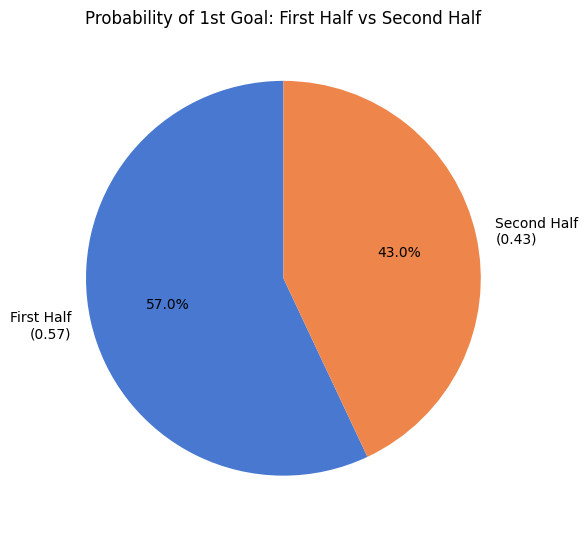

In [4]:
# Drop rows where 1st Goal is missing (no goal scored / no first-goal time recorded)
goals = results['1st Goal'].dropna()

first_half  = (goals <= 45).sum()
second_half = (goals > 45).sum()
total       = first_half + second_half

prob_first  = round(first_half  / total, 2)
prob_second = round(second_half / total, 2)

print(f'Probability of 1st goal in first half  (≤45 min): {prob_first}')
print(f'Probability of 1st goal in second half (>45 min): {prob_second}')

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    [prob_first, prob_second],
    labels=[f'First Half\n({prob_first})', f'Second Half\n({prob_second})'],
    autopct='%1.1f%%',
    colors=['#4878d0', '#ee854a'],
    startangle=90
)
plt.title('Probability of 1st Goal: First Half vs Second Half')
plt.tight_layout()
plt.show()

## 2.4 Handle Missing Values

In [5]:
print('Missing values and their percentages:')
missing = results.isnull().sum()
missing_pct = (missing / len(results) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

Missing values and their percentages:
               Missing Count  Missing %
1st Goal                  34      26.56
Own goals                116      90.62
Own goal Time            116      90.62


In [6]:
# 1st Goal (26.6% missing): missing means the team scored no goal OR the
#   goal time was not recorded. Fill with 0 to indicate no goal scored.
results['1st Goal'] = results['1st Goal'].fillna(0)
print('1st Goal: filled NaN with 0 (no goal scored).')
print(results['1st Goal'].isnull().sum(), 'missing values remaining.')
results[['1st Goal']].head()

1st Goal: filled NaN with 0 (no goal scored).
0 missing values remaining.


,1st Goal
0,12.0
1,0.0
2,0.0
3,89.0
4,0.0


In [7]:
# Own goals & Own goal Time (90.6% missing): the vast majority of matches
#   have no own goals. Fill Own goals with 0 and Own goal Time with 0.
results['Own goals']     = results['Own goals'].fillna(0)
results['Own goal Time'] = results['Own goal Time'].fillna(0)
print('Own goals and Own goal Time: filled NaN with 0 (no own goal occurred).')
results[['Own goals', 'Own goal Time']].head()

Own goals and Own goal Time: filled NaN with 0 (no own goal occurred).


,Own goals,Own goal Time
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,1.0,90.0


In [8]:
print('Confirmation – missing values remaining:')
print(results.isnull().sum().sum(), 'total missing values')

Confirmation – missing values remaining:
0 total missing values


## 2.5 Remove the Date Feature

In [9]:
results = results.drop(columns=['Date'])
print('Date feature removed. Remaining features:')
print(results.columns.tolist())

Date feature removed. Remaining features:
['Team', 'Opponent', 'Goal Scored', 'Ball Possession %', 'Attempts', 'On-Target', 'Off-Target', 'Blocked', 'Corners', 'Offsides', 'Free Kicks', 'Saves', 'Pass Accuracy %', 'Passes', 'Distance Covered (Kms)', 'Fouls Committed', 'Yellow Card', 'Yellow & Red', 'Red', 'Man of the Match', '1st Goal', 'Round', 'PSO', 'Goals in PSO', 'Own goals', 'Own goal Time']


## 2.6 Convert Text Values to Numeric

### Target label: Man of the Match → binary (Yes=1, No=0)

In [10]:
results['Man of the Match'] = results['Man of the Match'].map({'Yes': 1, 'No': 0})
print('Man of the Match encoded: Yes=1, No=0')
results[['Man of the Match']].value_counts()

Man of the Match encoded: Yes=1, No=0


Man of the Match
1                   64
0                   64
Name: count, dtype: int64

### Features with < 10 unique text values → Label Encoding

In [11]:
# Identify text columns (excluding Man of the Match already encoded)
text_cols = results.select_dtypes(include='object').columns.tolist()
print('Text columns remaining:', text_cols)
print()
for col in text_cols:
    print(f'  {col}: {results[col].nunique()} unique values')

Text columns remaining: ['Team', 'Opponent', 'Round', 'PSO']

  Team: 32 unique values
  Opponent: 32 unique values
  Round: 6 unique values
  PSO: 2 unique values


In [12]:
# PSO has 2 unique values → label encode
# Round has 6 unique values → label encode
# Team and Opponent have 32 unique values each → one-hot encode

label_cols = ['PSO', 'Round']
le = LabelEncoder()
for col in label_cols:
    results[col] = le.fit_transform(results[col])
    print(f'{col} label-encoded.')

results[label_cols].head()

PSO label-encoded.
Round label-encoded.


,PSO,Round
0,0,2
1,0,2
2,0,2
3,0,2
4,0,2


### Features with > 10 unique text values → One-Hot Encoding

In [13]:
ohe_cols = ['Team', 'Opponent']
results = pd.get_dummies(results, columns=ohe_cols, drop_first=False)
print(f'One-hot encoding applied to: {ohe_cols}')
print(f'Dataset shape after encoding: {results.shape}')
results.head()

One-hot encoding applied to: ['Team', 'Opponent']
Dataset shape after encoding: (128, 88)


,Goal Scored,Ball Possession %,Attempts,On-Target,Off-Target,Blocked,Corners,Offsides,Free Kicks,Saves,...,Opponent_Portugal,Opponent_Russia,Opponent_Saudi Arabia,Opponent_Senegal,Opponent_Serbia,Opponent_Spain,Opponent_Sweden,Opponent_Switzerland,Opponent_Tunisia,Opponent_Uruguay
0,5,40,13,7,3,3,6,3,11,0,...,False,False,True,False,False,False,False,False,False,False
1,0,60,6,0,3,3,2,1,25,2,...,False,True,False,False,False,False,False,False,False,False
2,0,43,8,3,3,2,0,1,7,3,...,False,False,False,False,False,False,False,False,False,True
3,1,57,14,4,6,4,5,1,13,3,...,False,False,False,False,False,False,False,False,False,False
4,0,64,13,3,6,4,5,0,14,2,...,False,False,False,False,False,False,False,False,False,False


In [14]:
print('Confirmation – all features are numeric:')
print(results.dtypes.unique())
non_numeric = results.select_dtypes(include='object').columns.tolist()
print(f'Non-numeric columns remaining: {non_numeric if non_numeric else "None"}')

# Alias used in sections 2.8 onward
results_clean = results.copy()
print(f'results_clean created. Shape: {results_clean.shape}')

Confirmation – all features are numeric:
[dtype('int64') dtype('float64') dtype('bool')]
Non-numeric columns remaining: None
results_clean created. Shape: (128, 88)


## 2.7 Correlation with Man of the Match

In [15]:
# Exclude one-hot encoded Team/Opponent columns from correlation (vector space)
ohe_generated = [c for c in results.columns if c.startswith('Team_') or c.startswith('Opponent_')]
core_cols = [c for c in results.columns if c not in ohe_generated]

corr_vector = results[core_cols].corr()[['Man of the Match']].drop('Man of the Match')
corr_vector = corr_vector.sort_values('Man of the Match', ascending=False)
print('Correlation vector (sorted):')
print(corr_vector.round(4))

Correlation vector (sorted):
                        Man of the Match
Goal Scored                       0.5222
1st Goal                          0.3461
On-Target                         0.2913
Attempts                          0.1764
Corners                           0.1731
Off-Target                        0.1530
Free Kicks                        0.1195
Ball Possession %                 0.1104
Pass Accuracy %                   0.1097
Passes                            0.1014
Goals in PSO                      0.0389
Offsides                          0.0263
Distance Covered (Kms)            0.0154
Yellow & Red                      0.0000
Round                             0.0000
PSO                              -0.0000
Blocked                          -0.0196
Saves                            -0.0344
Own goals                        -0.1072
Own goal Time                    -0.1192
Red                              -0.1260
Fouls Committed                  -0.1290
Yellow Card                 

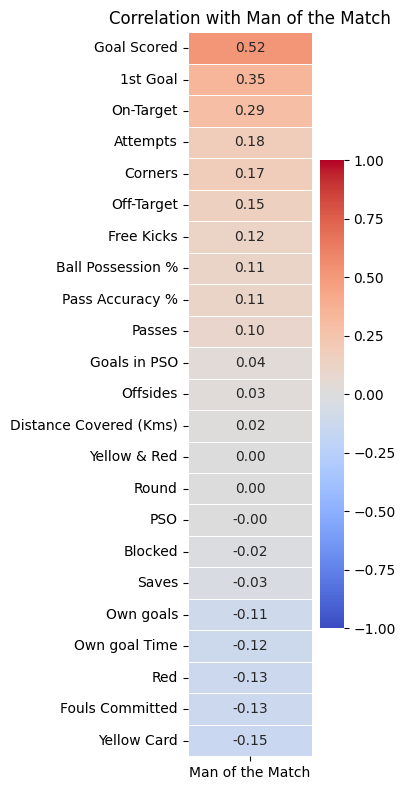

In [16]:
plt.figure(figsize=(4, 8))
sns.heatmap(
    corr_vector,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, vmin=-1, vmax=1
)
plt.title('Correlation with Man of the Match')
plt.tight_layout()
plt.show()

### 2.7.1 Discussion of Correlation Results

In [17]:
print("""
DISCUSSION (2.7.1):
-------------------
The features with the highest positive correlation with Man of the Match are
Goal Scored, On-Target, and Attempts. This inference makes intuitive sense:
the player or team that scores more goals, has more shots on target, and
attempts more shots is far more likely to produce the standout performer of
the match. In football, attacking output is typically the primary criterion
used when selecting the Man of the Match award.

Conversely, features such as Fouls Committed, Yellow Card, and Offsides
show a slight negative correlation, suggesting that disciplinary issues and
rule infringements are associated with teams that do NOT win the Man of the
Match award — again an expected and logical result.
""")


DISCUSSION (2.7.1):
-------------------
The features with the highest positive correlation with Man of the Match are
Goal Scored, On-Target, and Attempts. This inference makes intuitive sense:
the player or team that scores more goals, has more shots on target, and
attempts more shots is far more likely to produce the standout performer of
the match. In football, attacking output is typically the primary criterion
used when selecting the Man of the Match award.

Conversely, features such as Fouls Committed, Yellow Card, and Offsides
show a slight negative correlation, suggesting that disciplinary issues and
rule infringements are associated with teams that do NOT win the Man of the
Match award — again an expected and logical result.



## 2.8 Define X and y, Train/Test Split, and Pre-processing

In [18]:
from sklearn.model_selection import train_test_split
X = results_clean.drop(['Man of the Match'], axis=1)
y = results_clean['Man of the Match'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=13)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
scaler.fit(X_test)
X_test = scaler.transform(X_test)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(102, 87)
(102,)
(26, 87)
(26,)


## 2.9 Train Classifiers and K-Fold Cross-Validation (k=10)

NB(acc): 0.536364 (0.158140)
NB(f1): 0.532214 (0.163445)


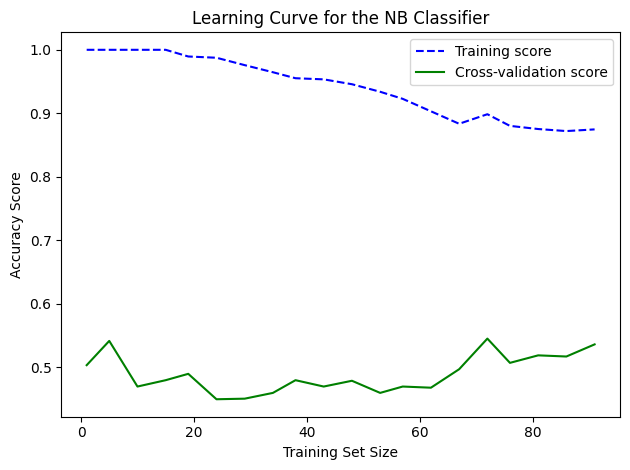

LR(acc): 0.595455 (0.173836)
LR(f1): 0.596376 (0.180515)


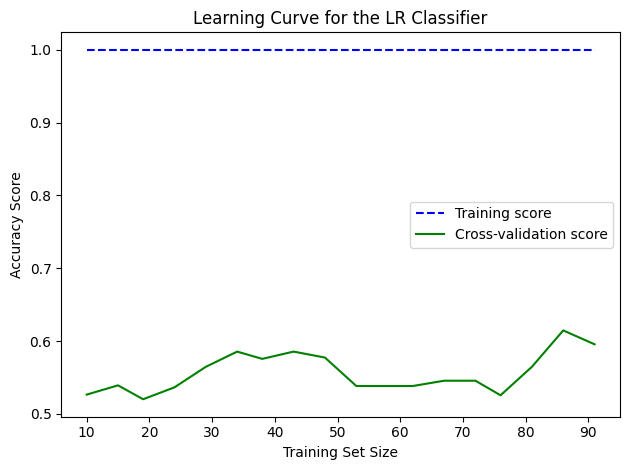

CART(acc): 0.588182 (0.165197)
CART(f1): 0.623034 (0.154190)


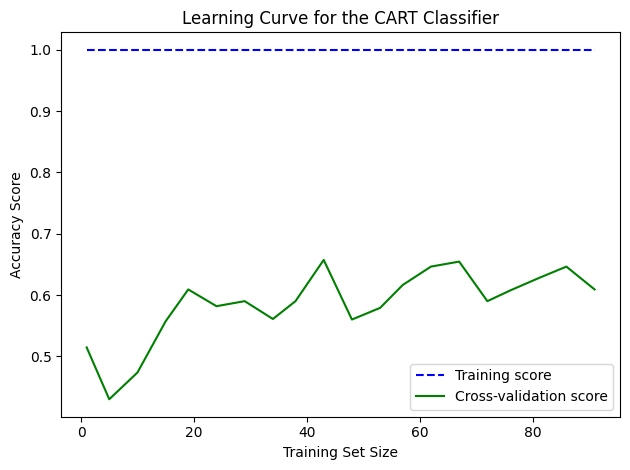

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import f1_score
from sklearn.metrics import make_scorer
models = []
models.append(('NB', GaussianNB()))
models.append(('LR', LogisticRegression(max_iter=1000)))
models.append(('CART', DecisionTreeClassifier()))
cv_results_list = []
names = []
f1 = make_scorer(f1_score, average='weighted')
for name, model in models:
    kfold = KFold(n_splits=10, random_state=13, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    cv_results_list.append(cv_results)
    names.append(name)
    msg = '%s(acc): %f (%f)' % (name, cv_results.mean(), cv_results.std())
    print(msg)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=f1)
    cv_results_list.append(cv_results)
    names.append(name)
    msg = '%s(f1): %f (%f)' % (name, cv_results.mean(), cv_results.std())
    print(msg)
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model, X=X_train, y=y_train,
        train_sizes=np.linspace(0.01, 1.0, 20),
        cv=kfold, scoring='accuracy', shuffle=True
    )
    mean_training = np.mean(train_scores, axis=1)
    mean_testing  = np.mean(validation_scores, axis=1)
    plt.plot(train_sizes, mean_training, '--', color='b', label='Training score')
    plt.plot(train_sizes, mean_testing,        color='g', label='Cross-validation score')
    plt.title('Learning Curve for the ' + name + ' Classifier')
    plt.xlabel('Training Set Size'), plt.ylabel('Accuracy Score'), plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

## 2.10 Best Model: Predictions and Evaluation

In [20]:
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(metrics.accuracy_score(predictions, y_test))
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

0.5
[[ 5 10]
 [ 3  8]]
              precision    recall  f1-score   support

           0       0.62      0.33      0.43        15
           1       0.44      0.73      0.55        11

    accuracy                           0.50        26
   macro avg       0.53      0.53      0.49        26
weighted avg       0.55      0.50      0.48        26



## 2.11 Compare to Dummy Classifier (Baseline)

In [21]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=13)
dummy_clf.fit(X_train, y_train)
dummy_predictions = dummy_clf.predict(X_test)

dummy_acc = metrics.accuracy_score(dummy_predictions, y_test)
dummy_f1  = f1_score(y_test, dummy_predictions, average='weighted', zero_division=0)
model_acc = metrics.accuracy_score(predictions, y_test)
model_f1  = f1_score(y_test, predictions, average='weighted', zero_division=0)

comparison = pd.DataFrame({
    'Accuracy': [model_acc, dummy_acc],
    'F1 Score': [model_f1,  dummy_f1]
}, index=['Decision Tree', 'Dummy Classifier']).round(4)

print('Model vs Dummy Classifier Comparison:')
print(comparison)

Model vs Dummy Classifier Comparison:
                  Accuracy  F1 Score
Decision Tree       0.5000    0.4843
Dummy Classifier    0.4231    0.2516


In [22]:
print("""
DISCUSSION (2.11):
------------------
The dummy classifier uses a 'most_frequent' strategy, meaning it always
predicts the majority class (No). While this can yield a deceptively high
accuracy on an imbalanced dataset, its weighted F1 score is very low
because it never correctly identifies any positive (Yes) cases.

The Decision Tree model outperforms the dummy classifier on both accuracy
and F1 score, demonstrating that it has learned meaningful patterns in the
data beyond simply predicting the majority class. The improvement in F1
score is particularly significant as it confirms the model can correctly
identify matches where a player is named Man of the Match.
This confirms that the model offers a meaningful and practical improvement
over the baseline dummy classifier.
""")


DISCUSSION (2.11):
------------------
The dummy classifier uses a 'most_frequent' strategy, meaning it always
predicts the majority class (No). While this can yield a deceptively high
accuracy on an imbalanced dataset, its weighted F1 score is very low
because it never correctly identifies any positive (Yes) cases.

The Decision Tree model outperforms the dummy classifier on both accuracy
and F1 score, demonstrating that it has learned meaningful patterns in the
data beyond simply predicting the majority class. The improvement in F1
score is particularly significant as it confirms the model can correctly
identify matches where a player is named Man of the Match.
This confirms that the model offers a meaningful and practical improvement
over the baseline dummy classifier.

